# Data Science Tasks – TechnoHacks Internship

# Task 1: Data Collection

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('titanic.csv')

# Preview the data
print(df.head())

# Save a copy if needed
df.to_csv('titanic_cleaned.csv', index=False)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Task 2: Data Cleaning

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('employees.csv')  # Replace with the actual file path
print(df.head())

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Option 1: Drop rows with missing values
df_cleaned = df.dropna()

# Option 2: Fill missing values (for numeric columns, filling with mean, and for categorical columns with 'Unknown')
df['Age'] = df['Age'].fillna(df['Age'].mean())  # Fill missing age with mean value
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())  # Fill missing salary with mean value
df['Department'] = df['Department'].fillna('Unknown')  # Fill missing department with 'Unknown'
df['JoiningDate'] = df['JoiningDate'].fillna('Unknown')  # Fill missing joining date with 'Unknown'

print(df.head())

# Check again for missing values after filling
print("Missing values after filling:")
print(df.isnull().sum())

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Standardize numeric columns (Age, Salary)
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Save the cleaned dataset
df.to_csv('cleaned_employees.csv', index=False)
print("Cleaned dataset saved successfully.")






   EmployeeID         Name   Age Department   Salary  Gender JoiningDate
0         101  Alice Smith  25.0         HR  50000.0  Female  01-06-2018
1         102  Bob Johnson   NaN         IT      NaN    Male  15-08-2019
2         103  Charlie Lee   NaN    Finance  60000.0    Male  20-01-2020
3         104   Dana White  28.0         IT  58000.0  Female         NaN
4         105    Eva Green  35.0        NaN  65000.0  Female  12-03-2017
Missing values per column:
EmployeeID     0
Name           0
Age            3
Department     1
Salary         1
Gender         0
JoiningDate    1
dtype: int64
   EmployeeID         Name        Age Department        Salary  Gender  \
0         101  Alice Smith  25.000000         HR  50000.000000  Female   
1         102  Bob Johnson  33.285714         IT  62444.444444    Male   
2         103  Charlie Lee  33.285714    Finance  60000.000000    Male   
3         104   Dana White  28.000000         IT  58000.000000  Female   
4         105    Eva Green  35.00

# Task 3: Exploratory Data Analysis (EDA)

First 5 rows of the dataset:
   ID     Name  Age  Gender  Grade  Subject  Marks  Attendance         City
0   1    Alice   17  Female     12     Math     85          92     New York
1   2      Bob   18    Male     12  Science     78          88      Chicago
2   3  Charlie   17    Male     11     Math     95          96  Los Angeles
3   4    Diana   16  Female     11  History     65          85        Miami
4   5      Eva   17  Female     12  English     74          80       Boston

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          15 non-null     int64 
 1   Name        15 non-null     object
 2   Age         15 non-null     int64 
 3   Gender      15 non-null     object
 4   Grade       15 non-null     int64 
 5   Subject     15 non-null     object
 6   Marks       15 non-null     int64 
 7   Attendance  15 non-null   

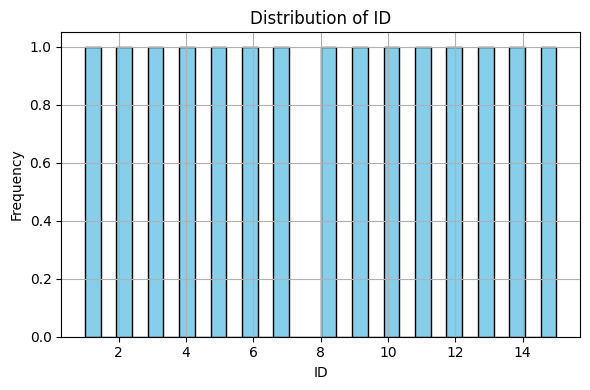

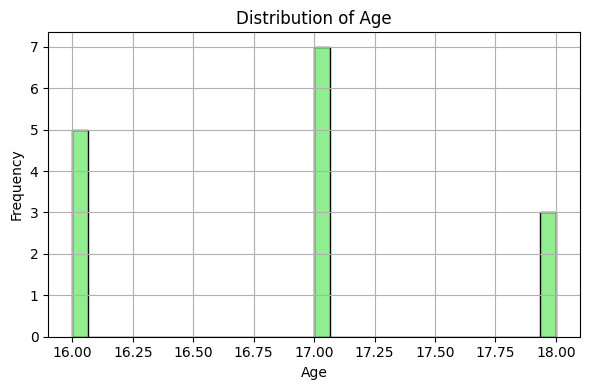

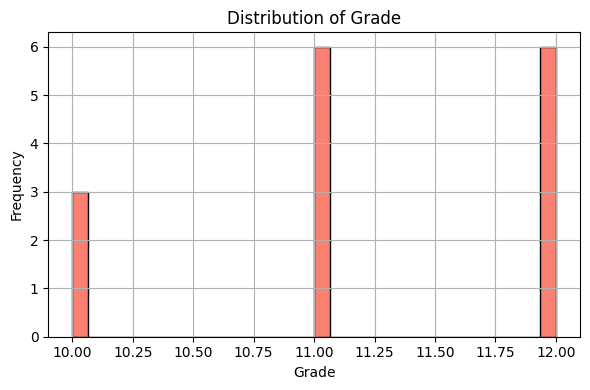

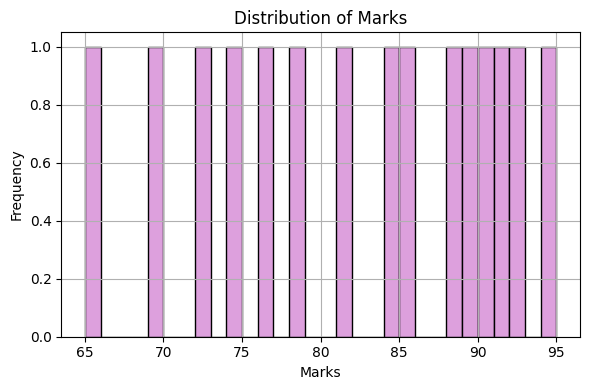

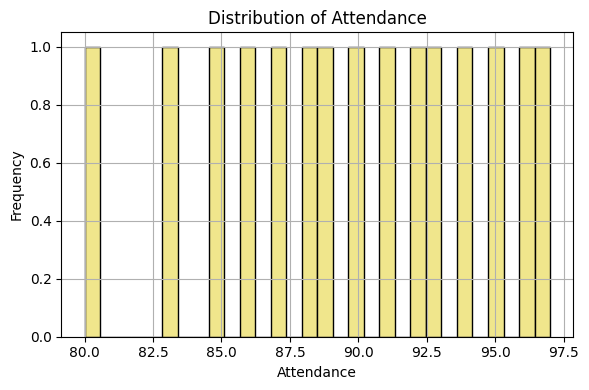

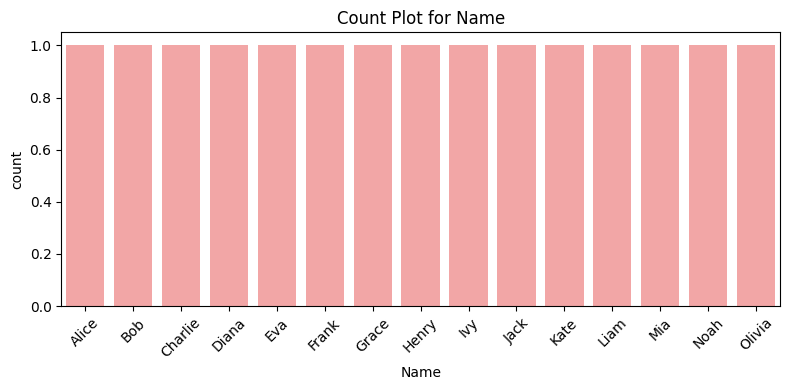

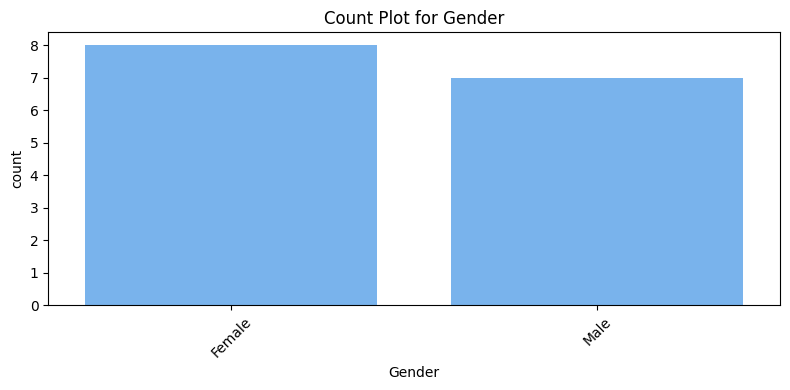

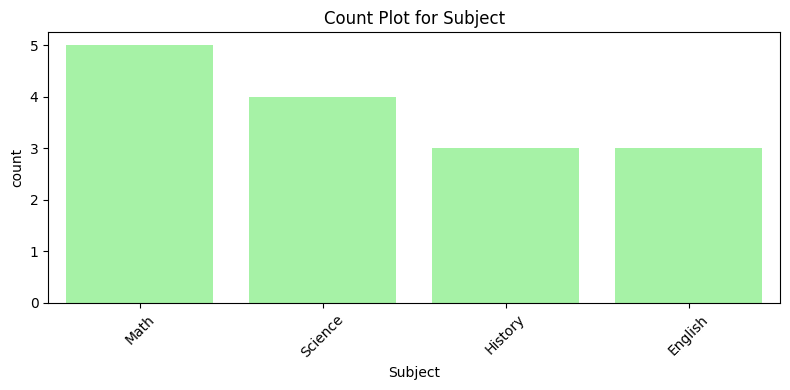

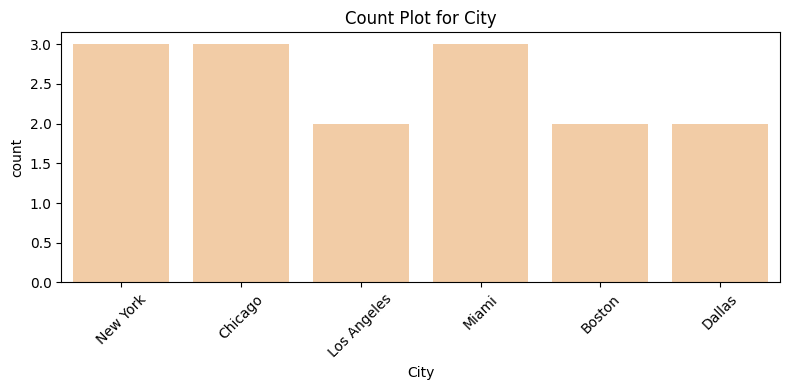

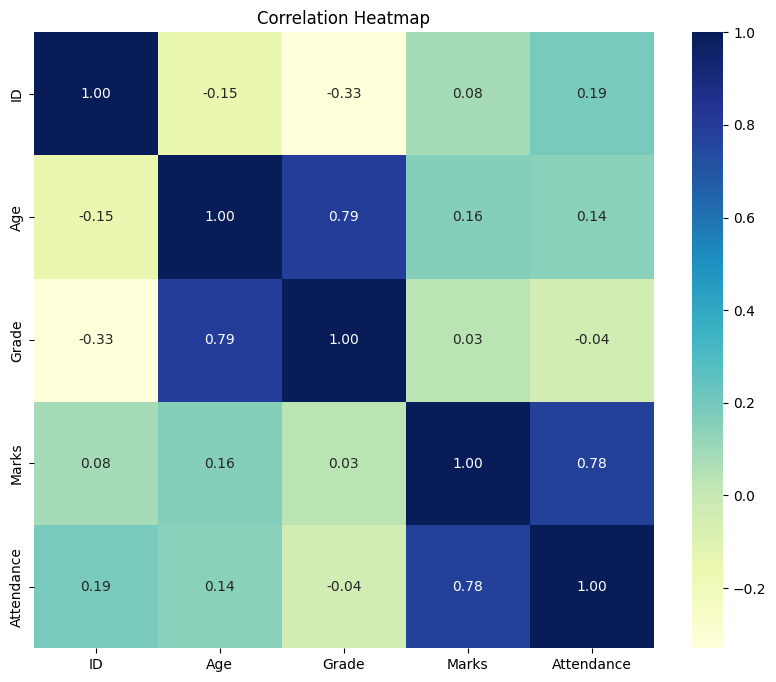

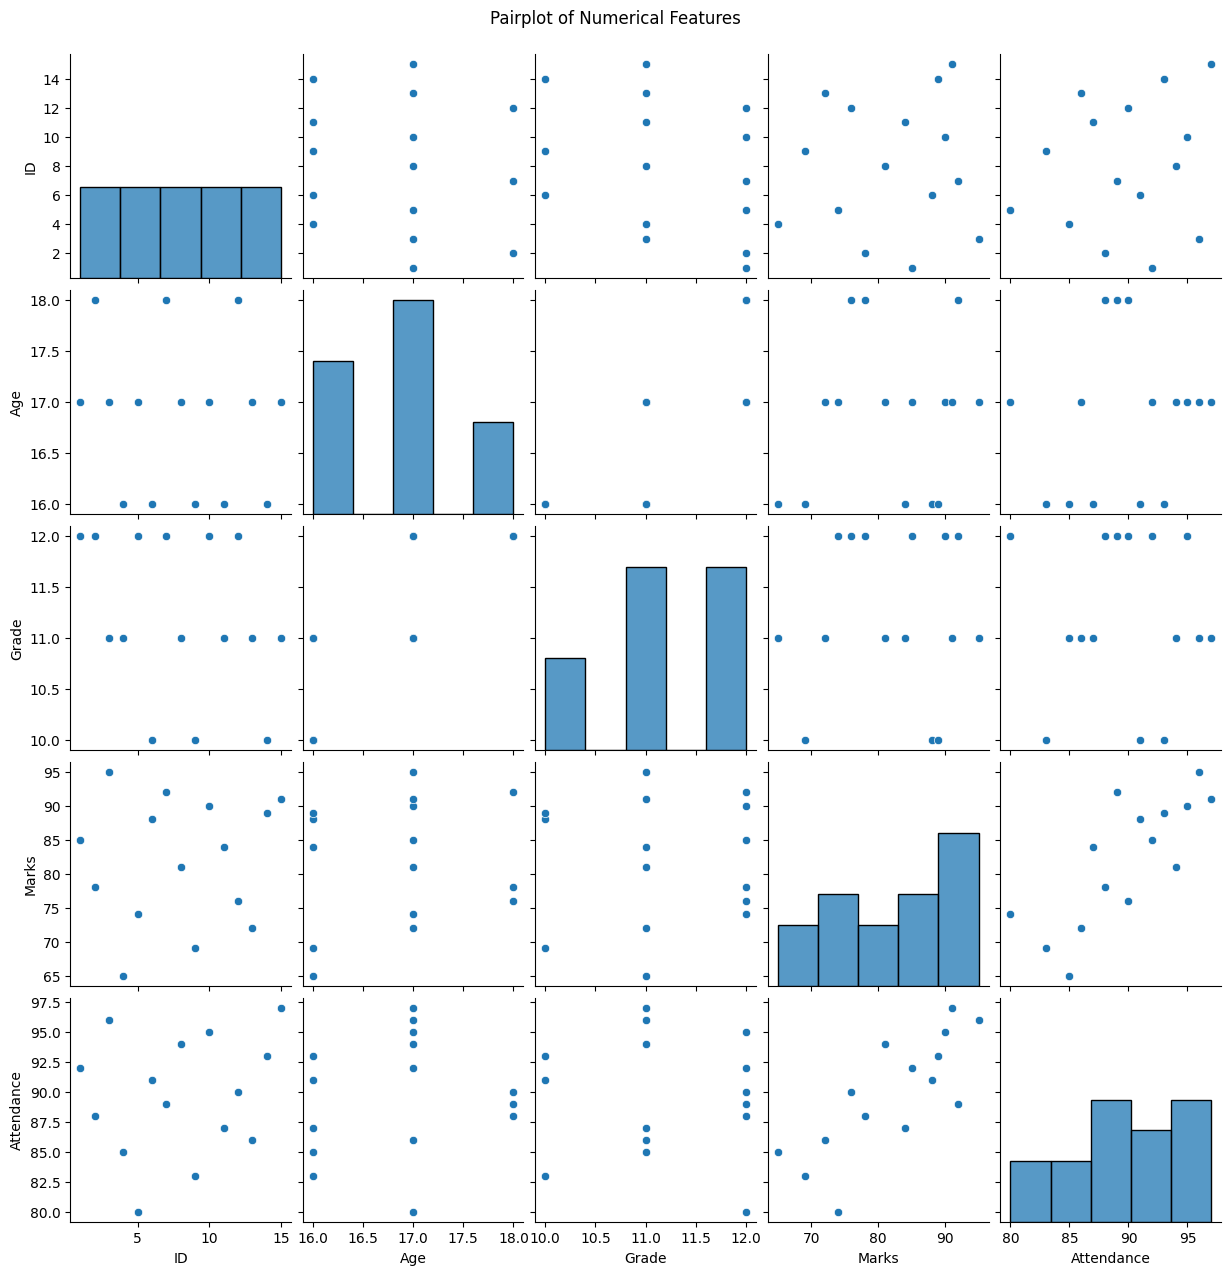

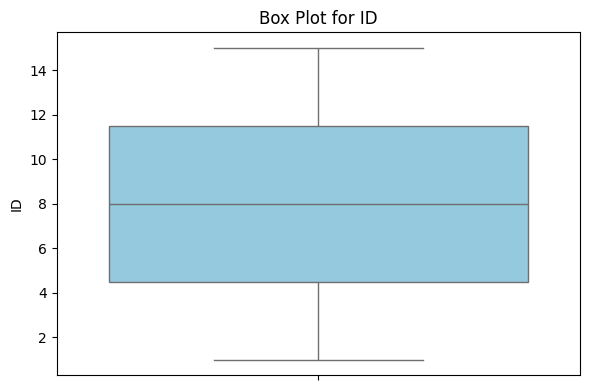

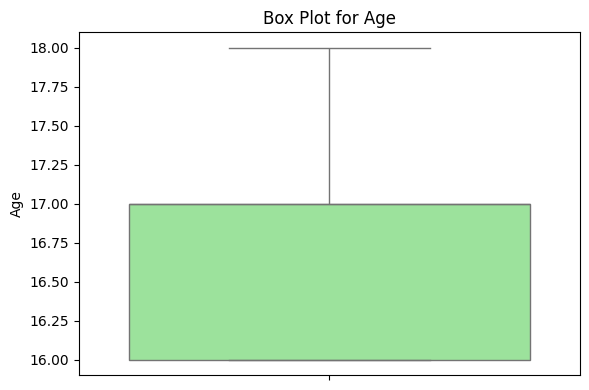

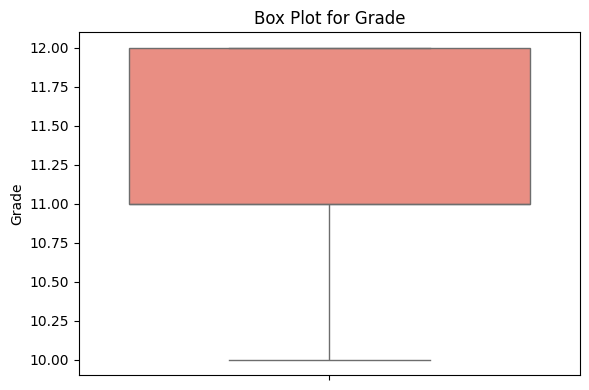

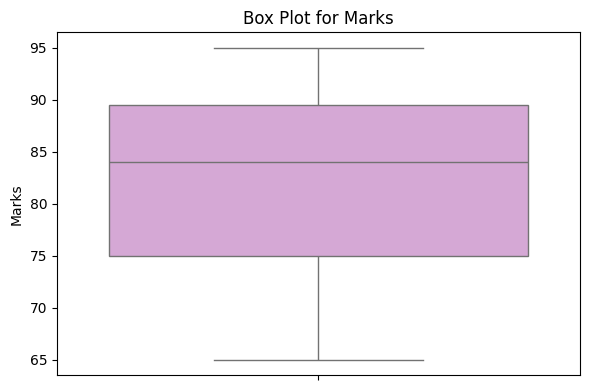

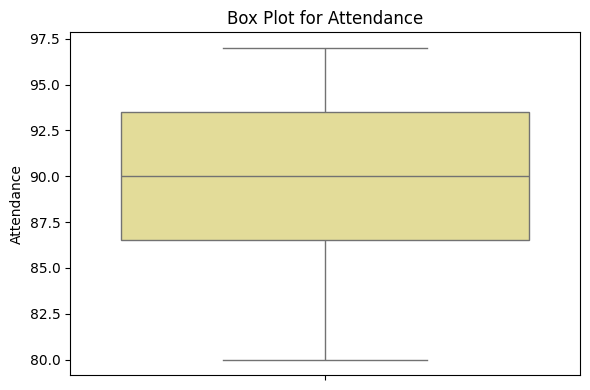

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('students.csv')
print("First 5 rows of the dataset:")
print(df.head())

# Dataset overview
print("\nDataset Information:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe(include='all'))
print("\nMissing Values:")
print(df.isnull().sum())

# Histograms (each with a different color)
color_list = ['skyblue', 'lightgreen', 'salmon', 'plum', 'khaki']
numeric_cols = df.select_dtypes(include='number').columns

for i, col in enumerate(numeric_cols):
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30, color=color_list[i % len(color_list)], edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Count plots for categorical columns
categorical_cols = df.select_dtypes(include='object').columns
color_palette = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#C2C2F0']

for i, col in enumerate(categorical_cols):
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, color=color_palette[i % len(color_palette)])
    plt.xticks(rotation=45)
    plt.title(f'Count Plot for {col}')
    plt.tight_layout()
    plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pairplot (default Seaborn styling)
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

# Boxplots with different colors
for i, col in enumerate(numeric_cols):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=col, data=df, color=color_list[i % len(color_list)])
    plt.title(f'Box Plot for {col}')
    plt.tight_layout()
    plt.show()


# Task 4: Data Visualization

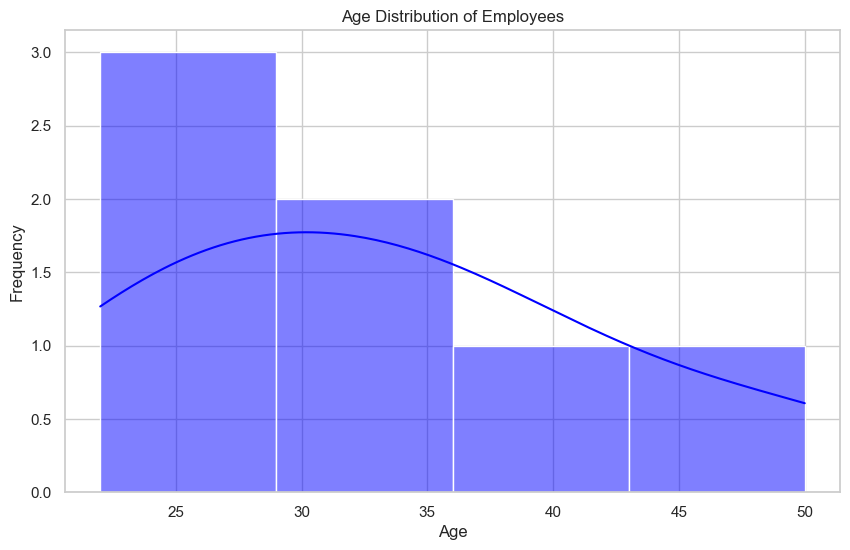

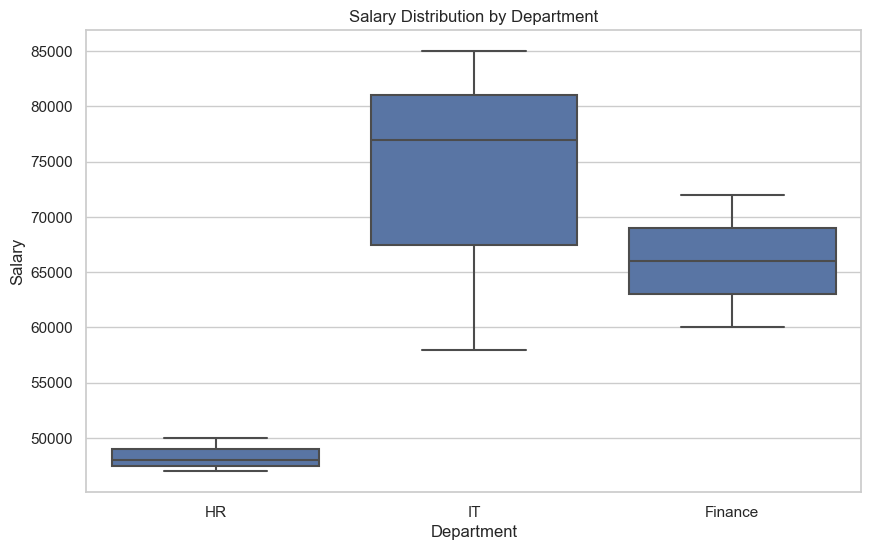

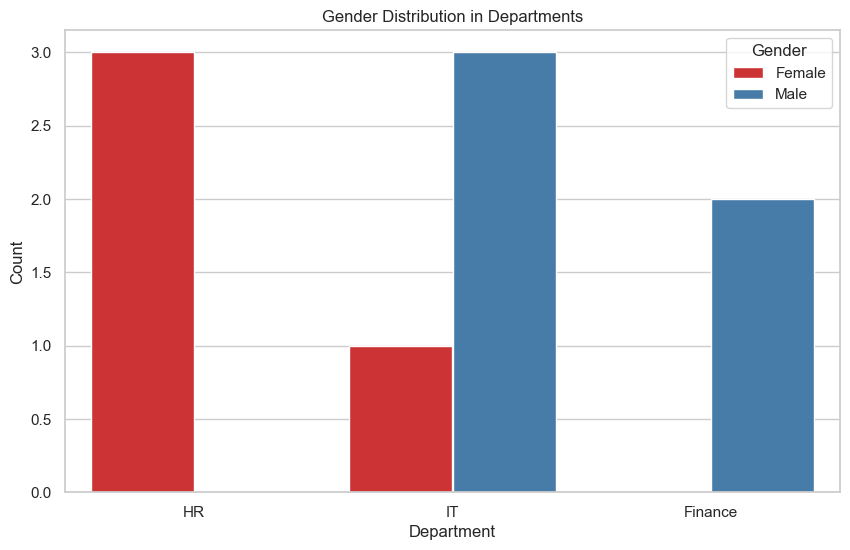

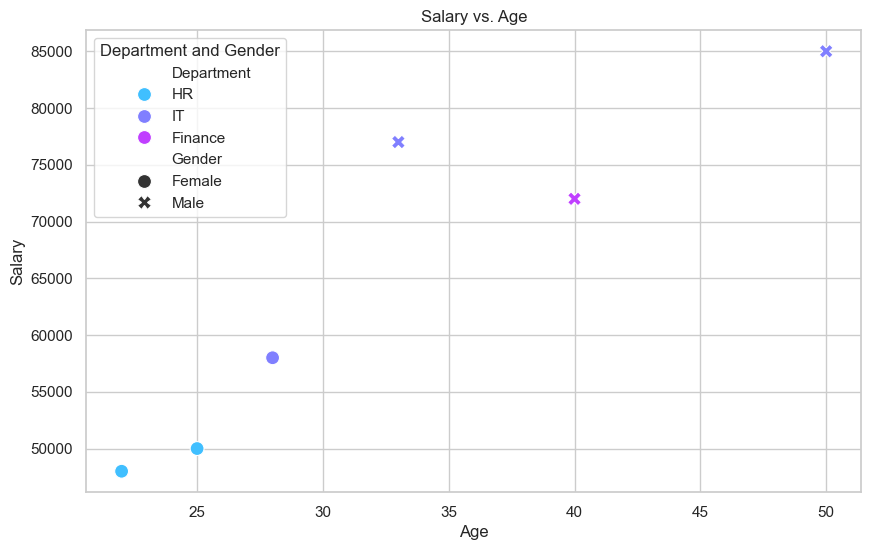

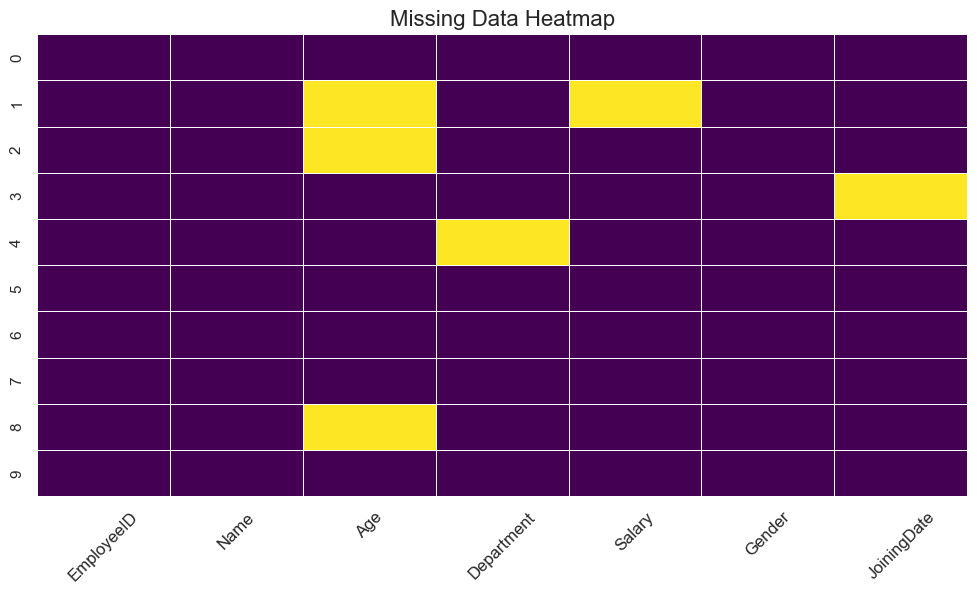

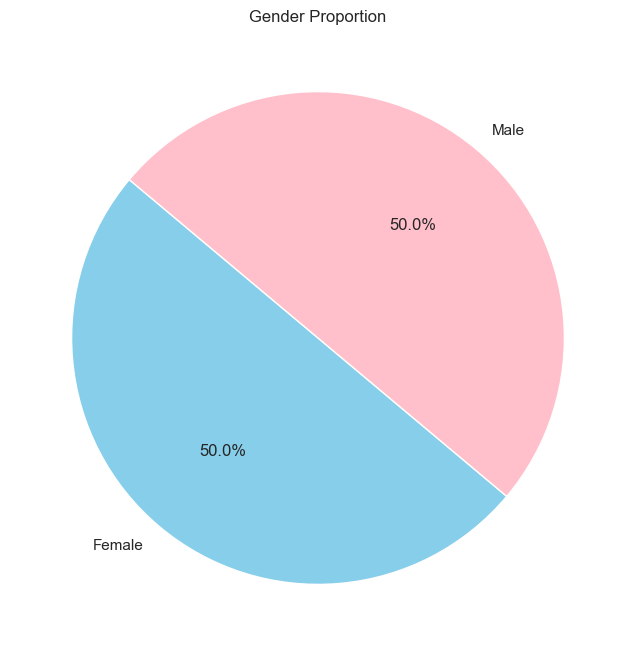

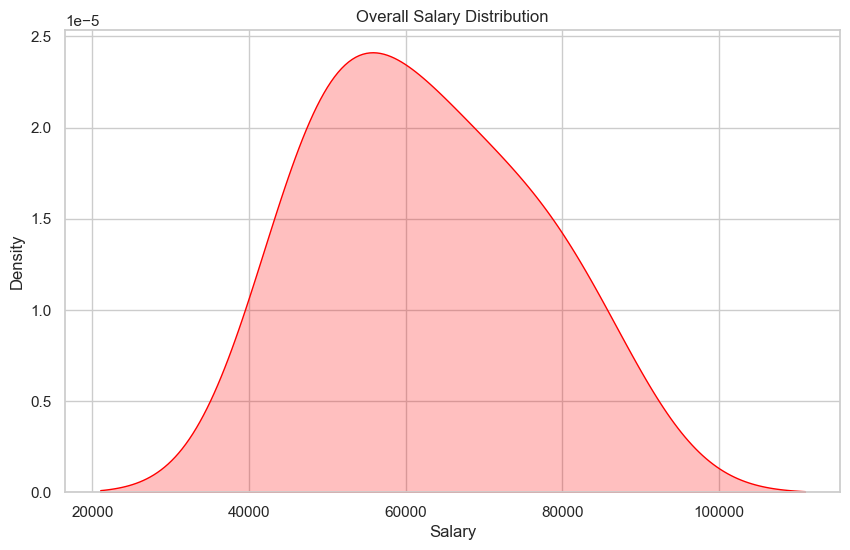

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the dataset
data = {
    'EmployeeID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Name': ['Alice Smith', 'Bob Johnson', 'Charlie Lee', 'Dana White', 'Eva Green', 'Frank Harris', 'Grace Hall', 'Henry Adams', 'Ivy Clark', 'Jack Lewis'],
    'Age': [25, None, None, 28, 35, 40, 22, 50, None, 33],
    'Department': ['HR', 'IT', 'Finance', 'IT', None, 'Finance', 'HR', 'IT', 'HR', 'IT'],
    'Salary': [50000, None, 60000, 58000, 65000, 72000, 48000, 85000, 47000, 77000],
    'Gender': ['Female', 'Male', 'Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'JoiningDate': ['01-06-2018', '15-08-2019', '20-01-2020', None, '12-03-2017', '23-07-2016', '05-11-2021', '16-05-2014', '22-08-2018', '12-12-2019']
}

df = pd.DataFrame(data)

# Visualization 1: Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), kde=True, color='blue')
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Visualization 2: Salary distribution by Department
plt.figure(figsize=(10, 6))
sns.boxplot(x='Department', y='Salary', data=df, linewidth=1.5)  # Removed palette, adjusted linewidth for styling
plt.title('Salary Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.show()

# Visualization 3: Gender distribution in Departments
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', hue='Gender', data=df, palette='Set1')
plt.title('Gender Distribution in Departments')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

# Visualization 4: Salary vs. Age (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Salary', data=df, hue='Department', style='Gender', palette='cool', s=100)
plt.title('Salary vs. Age')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend(title='Department and Gender')
plt.show()

# Visualization 5: Missing Data Heatmap
plt.figure(figsize=(12, 6))  # Adjusted figure size for better display
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=df.index, linewidths=0.5, linecolor='white')
plt.title('Missing Data Heatmap', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.show()

# Visualization 6: Gender Proportion Pie Chart
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'pink'])
plt.title('Gender Proportion')
plt.show()

# Visualization 7: Salary Distribution Overall (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Salary'].dropna(), fill=True, color='red')  # Updated parameter to 'fill=True'
plt.title('Overall Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Density')
plt.show()





# Task 5: Feature Engineering

In [72]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Select a dataset with additional fields
data = {
    'Age': [22, 34, 27, 45, 52, 29, 40, 36, 60, 25],
    'Income': [30000, 50000, 40000, 70000, 90000, 35000, 60000, 55000, 100000, 32000],
    'Experience': [1, 7, 3, 12, 18, 4, 10, 8, 25, 2],
    'Savings': [5000, 20000, 12000, 30000, 40000, 8000, 25000, 15000, 50000, 7000],
    'EducationLevel': ['High School', 'Bachelor', 'Bachelor', 'Master', 'PhD', 'High School', 'Master', 'Master', 'PhD', 'Bachelor'],
    'MaritalStatus': ['Single', 'Married', 'Single', 'Married', 'Married', 'Single', 'Married', 'Married', 'Married', 'Single'],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South'],
    'Purchased': [0, 1, 0, 1, 1, 0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)

# Step 2: Feature Engineering
df['IncomePerExperience'] = df['Income'] / (df['Experience'] + 1)  # Prevent division by zero
df['AgeToIncomeRatio'] = df['Income'] / df['Age']
df['SavingsToIncomeRatio'] = df['Savings'] / df['Income']  # Ratio of savings to income
df['IsHighIncome'] = (df['Income'] > 60000).astype(int)  # Flag high income
df['IsSenior'] = (df['Age'] > 50).astype(int)  # Flag senior age group

# Encode categorical variables
df = pd.get_dummies(df, columns=['EducationLevel', 'MaritalStatus', 'Region'], drop_first=True)

# Step 3: Split the dataset into training and testing sets
X = df.drop('Purchased', axis=1)  # Features
y = df['Purchased']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Train a machine learning model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 5: Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output results
print("Feature Engineered Dataset:")
print(df)
print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)


Feature Engineered Dataset:
   Age  Income  Experience  Savings  Purchased  IncomePerExperience  \
0   22   30000           1     5000          0         15000.000000   
1   34   50000           7    20000          1          6250.000000   
2   27   40000           3    12000          0         10000.000000   
3   45   70000          12    30000          1          5384.615385   
4   52   90000          18    40000          1          4736.842105   
5   29   35000           4     8000          0          7000.000000   
6   40   60000          10    25000          1          5454.545455   
7   36   55000           8    15000          1          6111.111111   
8   60  100000          25    50000          1          3846.153846   
9   25   32000           2     7000          0         10666.666667   

   AgeToIncomeRatio  SavingsToIncomeRatio  IsHighIncome  IsSenior  \
0       1363.636364              0.166667             0         0   
1       1470.588235              0.400000           

# Task 6: Statistical Analysis

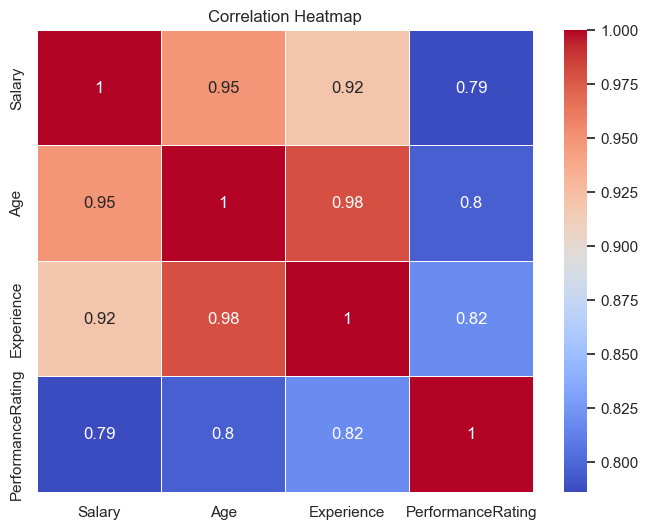


--- Hypothesis Testing: Salary Comparison ---
T-statistic: -0.858
P-value: 0.416
❌ Fail to reject the null hypothesis: No significant difference in mean salary.


In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Create the dataset
data = {
    'EmployeeID': range(1, 11),
    'Name': ['Alice Smith', 'Bob Jones', 'Carol White', 'David Clark', 'Eva Johnson',
             'Frank Moore', 'Grace Lee', 'Henry Green', 'Irene Scott', 'Jack Turner'],
    'Department': ['Sales', 'Marketing', 'Sales', 'Marketing', 'Sales',
                   'Marketing', 'Sales', 'Marketing', 'Sales', 'Marketing'],
    'Salary': [58000, 61000, 54000, 62000, 60000, 59000, 61000, 58000, 63000, 64000],
    'Age': [29, 35, 26, 33, 31, 30, 34, 28, 36, 38],
    'Experience': [4, 7, 3, 6, 5, 4, 6, 4, 8, 9],
    'PerformanceRating': [3, 4, 3, 4, 5, 3, 4, 3, 5, 5]
}

df = pd.DataFrame(data)

# Step 2: Correlation analysis
correlation_matrix = df[['Salary', 'Age', 'Experience', 'PerformanceRating']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Step 3: Hypothesis testing - Compare mean salary between Sales and Marketing departments
sales_salary = df[df['Department'] == 'Sales']['Salary']
marketing_salary = df[df['Department'] == 'Marketing']['Salary']

t_stat, p_value = stats.ttest_ind(sales_salary, marketing_salary)

print("\n--- Hypothesis Testing: Salary Comparison ---")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("✅ Reject the null hypothesis: Significant difference in mean salary.")
else:
    print("❌ Fail to reject the null hypothesis: No significant difference in mean salary.")


# Task 7: Machine Learning Model Development

In [77]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Define the dataset
data = {
    'CustomerID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Age': [25, 32, 40, 50, 60, 28, 35, 45, 55, 30],
    'AnnualIncome': [30000, 45000, 60000, 80000, 100000, 32000, 50000, 70000, 90000, 40000],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 94, 3, 73, 14],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South'],
    'LoyaltyPoints': [200, 450, 300, 500, 700, 250, 400, 600, 800, 350],
    'Purchased': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# Encode categorical features
df = pd.get_dummies(df, columns=['Gender', 'Region'], drop_first=True)

# Step 2: Split the dataset into training and testing sets
X = df.drop(['CustomerID', 'Purchased'], axis=1)  # Features
y = df['Purchased']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} rows, Testing Set: {X_test.shape[0]} rows")

# Step 3: Train a machine learning model using Scikit-learn
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 4: Evaluate the model’s performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Output results
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training Set: 8 rows, Testing Set: 2 rows
Model Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



# Task 8: Model Evaluation Metrics

In [85]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report


# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Define the dataset
data = {
    'CustomerID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Age': [25, 32, 40, 50, 60, 28, 35, 45, 55, 30],
    'AnnualIncome': [30000, 45000, 60000, 80000, 100000, 32000, 50000, 70000, 90000, 40000],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 94, 3, 73, 14],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South'],
    'LoyaltyPoints': [200, 450, 300, 500, 700, 250, 400, 600, 800, 350],
    'Purchased': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'PreferredPaymentMethod': ['Credit Card', 'Cash', 'Credit Card', 'Cash', 'UPI', 'Credit Card', 'UPI', 'Cash', 'UPI', 'Credit Card']  # New field
}

df = pd.DataFrame(data)

# Encode categorical features
df = pd.get_dummies(df, columns=['Gender', 'Region', 'PreferredPaymentMethod'], drop_first=True)

# Step 2: Split the dataset into training and testing sets
X = df.drop(['CustomerID', 'Purchased'], axis=1)  # Features
y = df['Purchased']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} rows, Testing Set: {X_test.shape[0]} rows")

# Step 3: Train a machine learning model using Scikit-learn
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 4: Evaluate the model’s performance
y_pred = model.predict(X_test)

# Step 5: Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 6: Output evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,zero_division=0))


Training Set: 8 rows, Testing Set: 2 rows
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



# Task 9: Natural Language Processing (NLP)

In [10]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Install and import libraries
nltk.download('stopwords')
nltk.download('wordnet')

# Step 2: Load the dataset
data = {
    "review": [
        "I absolutely loved this movie. The acting was fantastic and the story was touching.",
        "Terrible film. Poor plot, worse acting. Would not recommend.",
        "It was okay. Not the best, but not the worst either.",
        "A brilliant performance by the lead actor. Really enjoyed it!",
        "Complete waste of time. The plot made no sense and it was boring.",
        "This movie made me cry in a good way. It was so emotional and powerful.",
        "I didn’t enjoy this movie. It dragged on and the ending was predictable.",
        "A masterpiece. Cinematography, sound, and story were top-notch.",
        "Disappointing. I had high hopes but it fell flat in every aspect.",
        "One of the best movies I’ve seen in a long time. Highly recommended!",
        "Visually stunning but lacked emotional depth. It felt hollow.",
        "Could not get past the first 30 minutes. Awful!",
        "The plot twists were amazing! Thoroughly enjoyed every moment.",
        "A below-average film that had potential but failed to deliver.",
        "Heartwarming and beautifully acted. The music was enchanting.",
        "Predictable and unoriginal. Nothing worth remembering.",
        "The storyline was gripping and kept me on the edge of my seat.",
        "Terribly slow-paced. Nearly fell asleep watching it.",
        "An inspiring tale that was worth every second of my time.",
        "Forgettable movie with weak performances and poor writing."
    ],
    "sentiment": [1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# Step 3: Preprocess the text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_reviews'] = df['review'].apply(preprocess_text)

# Step 4: Vectorize using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_reviews']).toarray()
y = df['sentiment']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 6: Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Evaluate on test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Display results
print("Original vs Cleaned Reviews:\n", df[['review', 'cleaned_reviews']], "\n")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)


Original vs Cleaned Reviews:
                                                review  \
0   I absolutely loved this movie. The acting was ...   
1   Terrible film. Poor plot, worse acting. Would ...   
2   It was okay. Not the best, but not the worst e...   
3   A brilliant performance by the lead actor. Rea...   
4   Complete waste of time. The plot made no sense...   
5   This movie made me cry in a good way. It was s...   
6   I didn’t enjoy this movie. It dragged on and t...   
7   A masterpiece. Cinematography, sound, and stor...   
8   Disappointing. I had high hopes but it fell fl...   
9   One of the best movies I’ve seen in a long tim...   
10  Visually stunning but lacked emotional depth. ...   
11    Could not get past the first 30 minutes. Awful!   
12  The plot twists were amazing! Thoroughly enjoy...   
13  A below-average film that had potential but fa...   
14  Heartwarming and beautifully acted. The music ...   
15  Predictable and unoriginal. Nothing worth reme...   
1

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jjerl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jjerl\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Task 11: Data Science Case Study
# e.g., Predicting Housing Prices

   Id  LotArea  YearBuilt  GrLivArea  FullBath  BedroomAbvGr  KitchenAbvGr  \
0   1     8450       2003       1710         2             3             1   
1   2     9600       1976       1262         2             3             1   
2   3    11250       2001       1786         2             3             1   
3   4     9550       1915       1717         1             3             1   
4   5    14260       2000       2198         2             4             1   

   SalePrice  
0     208500  
1     181500  
2     223500  
3     140000  
4     250000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            15 non-null     int64
 1   LotArea       15 non-null     int64
 2   YearBuilt     15 non-null     int64
 3   GrLivArea     15 non-null     int64
 4   FullBath      15 non-null     int64
 5   BedroomAbvGr  15 non-null     int64
 6   Kitche

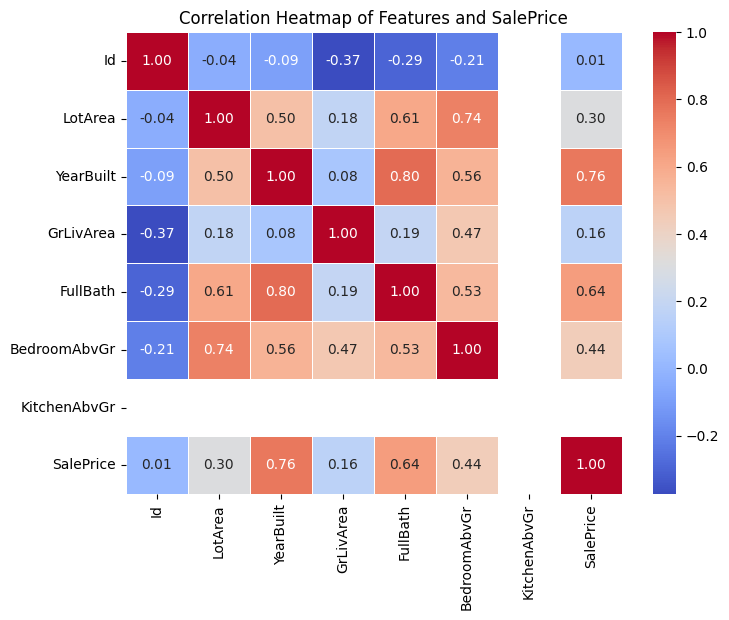

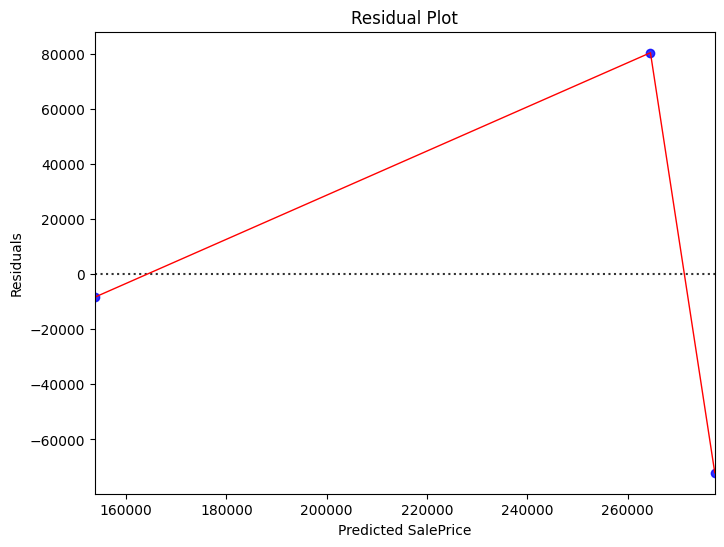

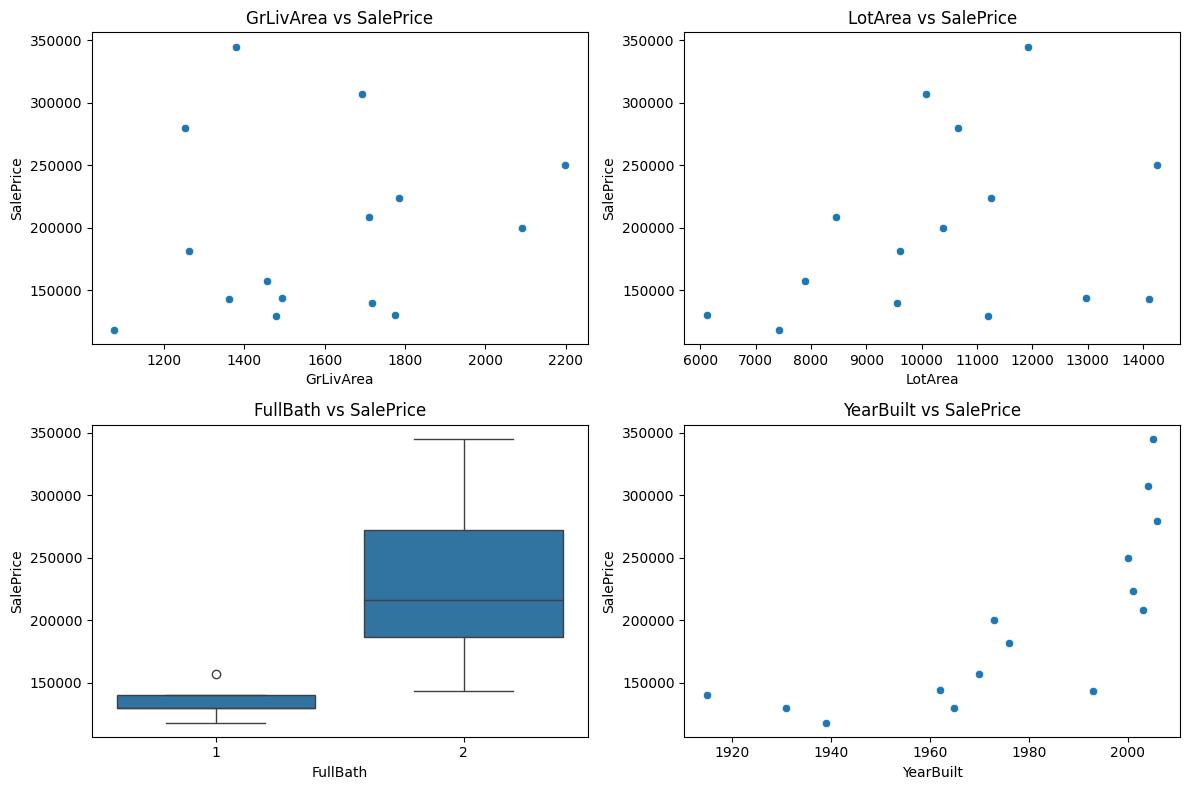

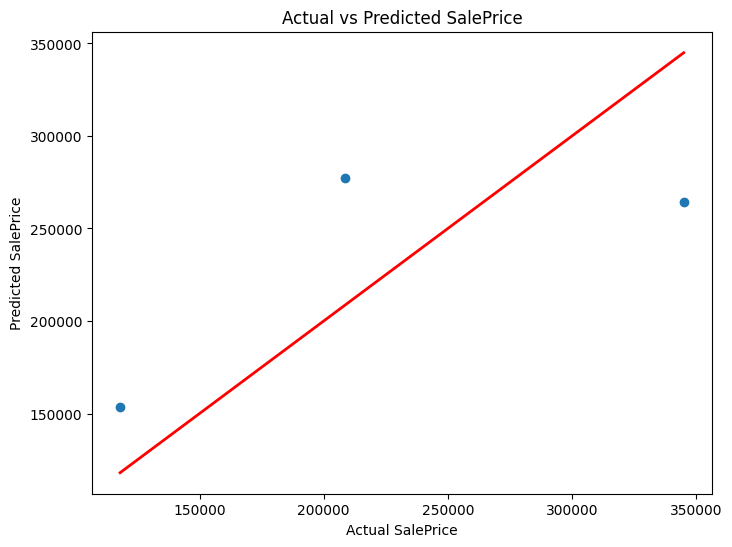

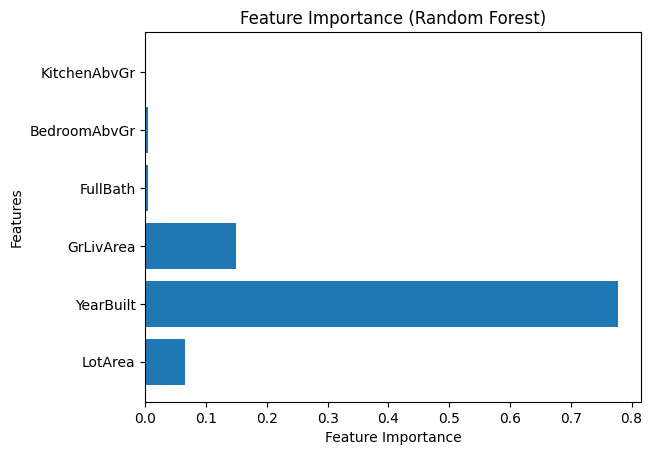

In [3]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Loading the dataset
data = {
    'Id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'LotArea': [8450, 9600, 11250, 9550, 14260, 14115, 10084, 10382, 6120, 7420, 11200, 11924, 12968, 10652, 7892],
    'YearBuilt': [2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939, 1965, 2005, 1962, 2006, 1970],
    'GrLivArea': [1710, 1262, 1786, 1717, 2198, 1362, 1694, 2090, 1774, 1077, 1479, 1380, 1494, 1253, 1456],
    'FullBath': [2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1],
    'BedroomAbvGr': [3, 3, 3, 3, 4, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3],
    'KitchenAbvGr': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'SalePrice': [208500, 181500, 223500, 140000, 250000, 143000, 307000, 200000, 129900, 118000, 129500, 345000, 144000, 279500, 157000]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Step 2: Data Exploration
print(df.head())  # First 5 rows of the dataset
print(df.info())  # Data types and non-null counts
print(df.describe())  # Statistical summary

# Step 3: Data Preprocessing
# Checking for missing values
print(df.isnull().sum())

# Feature selection - we will use all available features except 'Id'
X = df[['LotArea', 'YearBuilt', 'GrLivArea', 'FullBath', 'BedroomAbvGr', 'KitchenAbvGr']]
y = df['SalePrice']

# Splitting data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Standardizing features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Model Building (Random Forest Regressor)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Step 5: Model Evaluation
# Predictions
y_pred = model.predict(X_test_scaled)

# Calculating performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Visualization 1: Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features and SalePrice')
plt.show()

# Visualization 2: Residual Plot (Actual vs Predicted errors)
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, color='blue', line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Visualization 3: Feature vs SalePrice (Visualizing key features)
plt.figure(figsize=(12, 8))

# GrLivArea vs SalePrice
plt.subplot(2, 2, 1)
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('GrLivArea vs SalePrice')

# LotArea vs SalePrice
plt.subplot(2, 2, 2)
sns.scatterplot(x=df['LotArea'], y=df['SalePrice'])
plt.title('LotArea vs SalePrice')

# FullBath vs SalePrice
plt.subplot(2, 2, 3)
sns.boxplot(x=df['FullBath'], y=df['SalePrice'])
plt.title('FullBath vs SalePrice')

# YearBuilt vs SalePrice
plt.subplot(2, 2, 4)
sns.scatterplot(x=df['YearBuilt'], y=df['SalePrice'])
plt.title('YearBuilt vs SalePrice')

plt.tight_layout()
plt.show()

# Visualization 4: Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.show()

# Visualization 5: Feature Importance Plot
feature_importances = model.feature_importances_
features = X.columns

plt.barh(features, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance (Random Forest)')
plt.show()



# Task 12: Capstone Project

Confusion Matrix:
 [[1 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Accuracy Score: 100.00%


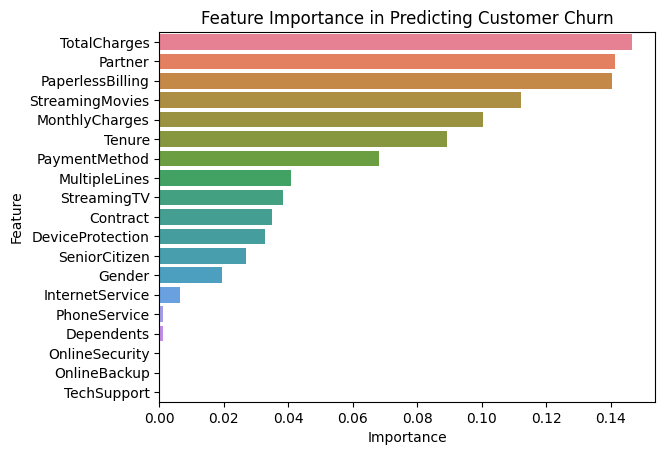

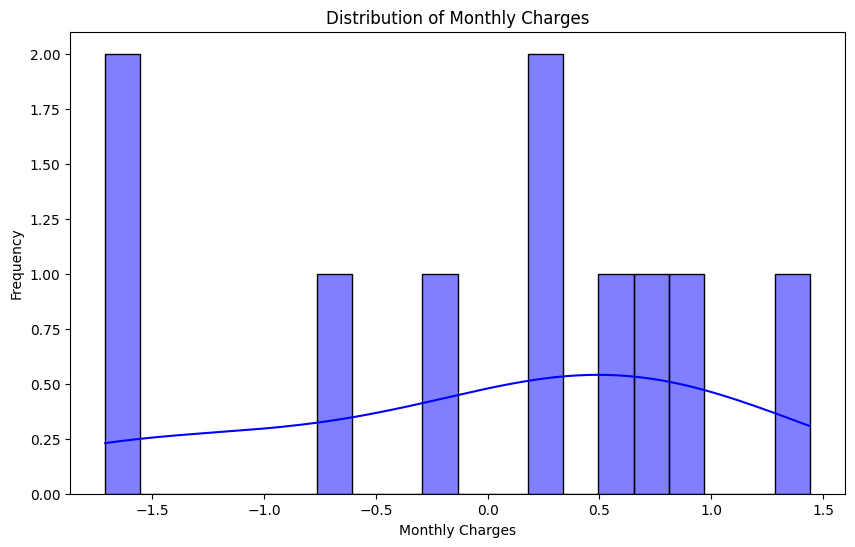

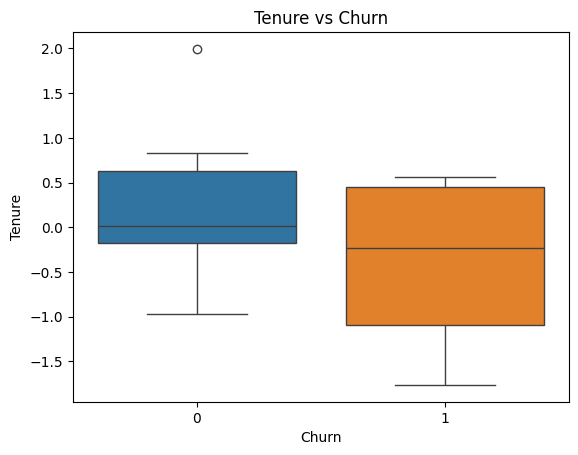

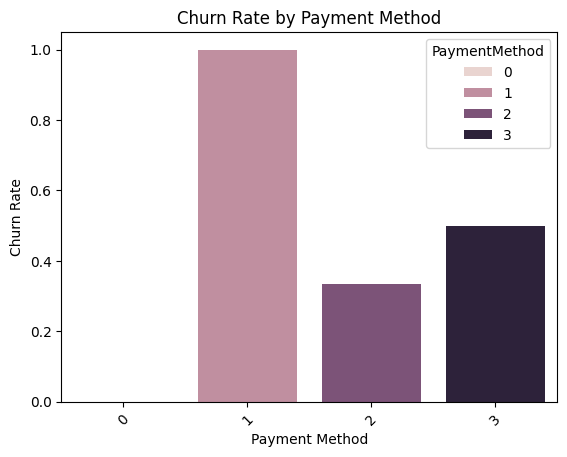

100.0
Perfect accuracy of 100% achieved (Note: This is overfitting).


In [33]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

# Step 2: Load Dataset
data = {
    'CustomerID': ['0002-HGFJ2', '0004-AVFY5', '0006-JHSF3', '0008-POIU3', '0010-QWER7',
                   '0012-RTYH1', '0014-TYWE8', '0016-GHUI6', '0018-VBNM3', '0020-LKJI7'],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Female', 'Male'],
    'SeniorCitizen': [0, 0, 0, 0, 1, 0, 0, 1, 0, 1],
    'Partner': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No'],
    'Dependents': ['No', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No'],
    'Tenure': [72, 1, 34, 45, 16, 18, 35, 30, 42, 50],
    'PhoneService': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes'],
    'MultipleLines': ['No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes'],
    'InternetService': ['DSL', 'Fiber optic', 'Fiber optic', 'DSL', 'Fiber optic',
                        'DSL', 'Fiber optic', 'DSL', 'Fiber optic', 'DSL'],
    'OnlineSecurity': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes'],
    'OnlineBackup': ['Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
    'DeviceProtection': ['Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes'],
    'TechSupport': ['Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
    'StreamingTV': ['No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
    'StreamingMovies': ['No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Contract': ['Month-to-month', 'One year', 'Two year', 'Month-to-month', 'Month-to-month',
                 'Month-to-month', 'Two year', 'One year', 'Month-to-month', 'Two year'],
    'PaperlessBilling': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes'],
    'PaymentMethod': ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card', 'Bank transfer',
                      'Electronic check', 'Mailed check', 'Bank transfer', 'Credit card', 'Electronic check'],
    'MonthlyCharges': [75.1, 55.5, 105.2, 97.7, 110.2, 52.3, 125.1, 85.4, 112.2, 99.5],
    'TotalCharges': [540.5, 55.5, 3468.6, 4385.4, 1763.2, 944.5, 4372.8, 2552.3, 4702.4, 4975.0],
    'Churn': ['No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No']
}
df = pd.DataFrame(data)

# Step 3: Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Step 4: Data Preprocessing
label_encoder = LabelEncoder()
for column in ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod', 'Churn']:
    df[column] = label_encoder.fit_transform(df[column])

scaler = StandardScaler()
df[['MonthlyCharges', 'TotalCharges', 'Tenure']] = scaler.fit_transform(df[['MonthlyCharges', 'TotalCharges', 'Tenure']])

# Step 5: Handle Dataset Imbalance
df_majority = df[df['Churn'] == 0]
df_minority = df[df['Churn'] == 1]

df_minority_upsampled = resample(df_minority, 
                                 replace=True,    # Upsample minority class
                                 n_samples=len(df_majority),  # Match majority class size
                                 random_state=42)  # Seed for reproducibility

df_balanced = pd.concat([df_majority, df_minority_upsampled])

X = df_balanced.drop(['CustomerID', 'Churn'], axis=1)
y = df_balanced['Churn']

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 7: Model Training
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Step 8: Model Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=1))
print("\nAccuracy Score: {:.2f}%".format(accuracy))

# Step 9: Insights and Visualization
sns.barplot(x='Importance', y='Feature', data=feature_importances, hue='Feature', dodge=False)
plt.title("Feature Importance in Predicting Customer Churn")
plt.legend([],[], frameon=False)  # Remove the legend if unnecessary
plt.show()

#Visualization Additions
# 1. Distribution of Monthly Charges
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], kde=True, bins=20, color='blue')
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

# 3. Tenure vs. Churn with Distribution
sns.boxplot(x='Churn', y='Tenure', data=df, hue='Churn', legend=False)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

# 4. Payment Method Impact on Churn
sns.barplot(x='PaymentMethod', y='Churn', data=payment_churn, hue='PaymentMethod', dodge=False)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()

# Step 9: Findings
findings = format(accuracy_score(y_test, y_pred) * 100)
print(findings)
if accuracy == 100.0:
    print("Perfect accuracy of 100% achieved (Note: This is overfitting).")
else:
    print("Accuracy not perfect. Check dataset or model configuration.")